In [ ]:
#connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install PyTorch Lightning and other library
!pip install pytorch-lightning --quiet
!pip install segmentation-models-pytorch rasterio --quiet

In [ ]:
import sys

# Project Path
path_ke_proyek = '/content/drive/MyDrive/Thesis/Running CL 16 Kelas/linkedin'

if path_ke_proyek not in sys.path:
    sys.path.append(path_ke_proyek)

### Preapareing Dataset

In [4]:
import pytorch_lightning as pl
from Model import sentinel_dataset
from Model import unet_model

In [ ]:
# DataModule Initialization
dm = sentinel_dataset.SentinelDataModule(
    train_dir=r"/content/drive/MyDrive/output_training/images",
    train_mask_dir=r"/content/drive/MyDrive/output_training/masks",
    test_dir=r"/content/drive/MyDrive/outpu_val/images",
    test_mask_dir=r"/content/drive/MyDrive/outpu_val/masks",
    batch_size=32,
    val_split=0.15 # Taking 10% of the train folder for validation
)

### Running The Model

In [ ]:
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger

#Model Initialization
model = unet_model.SentinelUNet()

#Checkpoint Model Configuration (Saving the best model)
checkpoint_callback = ModelCheckpoint(
    monitor="val_mIoU",            # Monitoring mIoU metrics on validation data
    mode="max",                    # We want the highest (maximum) mIoU
    save_top_k=1,                  # Only keep 1 best model
    filename="best-sentinel-unet",
    verbose=True
)

# Early Stopping Configuration (Stop if no progress)
early_stop_callback = EarlyStopping(
    monitor="val_loss",         # Monitoring loss in validation data
    patience=15,                # If during 10 epochs val_loss does not decrease, then stop
    mode="min",                 # We want the smallest (minimal) loss
    verbose=True
)

# Logger Initialization
csv_logger = CSVLogger("logs", name="sentinel_unet_experiment")

# Insert Callbacks into Trainer
trainer = pl.Trainer(
    max_epochs=100,
    accelerator="auto",
    devices=1,
    logger=csv_logger,
    log_every_n_steps=1, # note/save every batch information
    callbacks=[checkpoint_callback, early_stop_callback]
)

# Training & Validation
trainer.fit(model, datamodule=dm)

# Testing
# .test() will automatically load the best model from the training phase if using checkpoints
trainer.test(model, datamodule=dm)

### Visualization Learning Curves

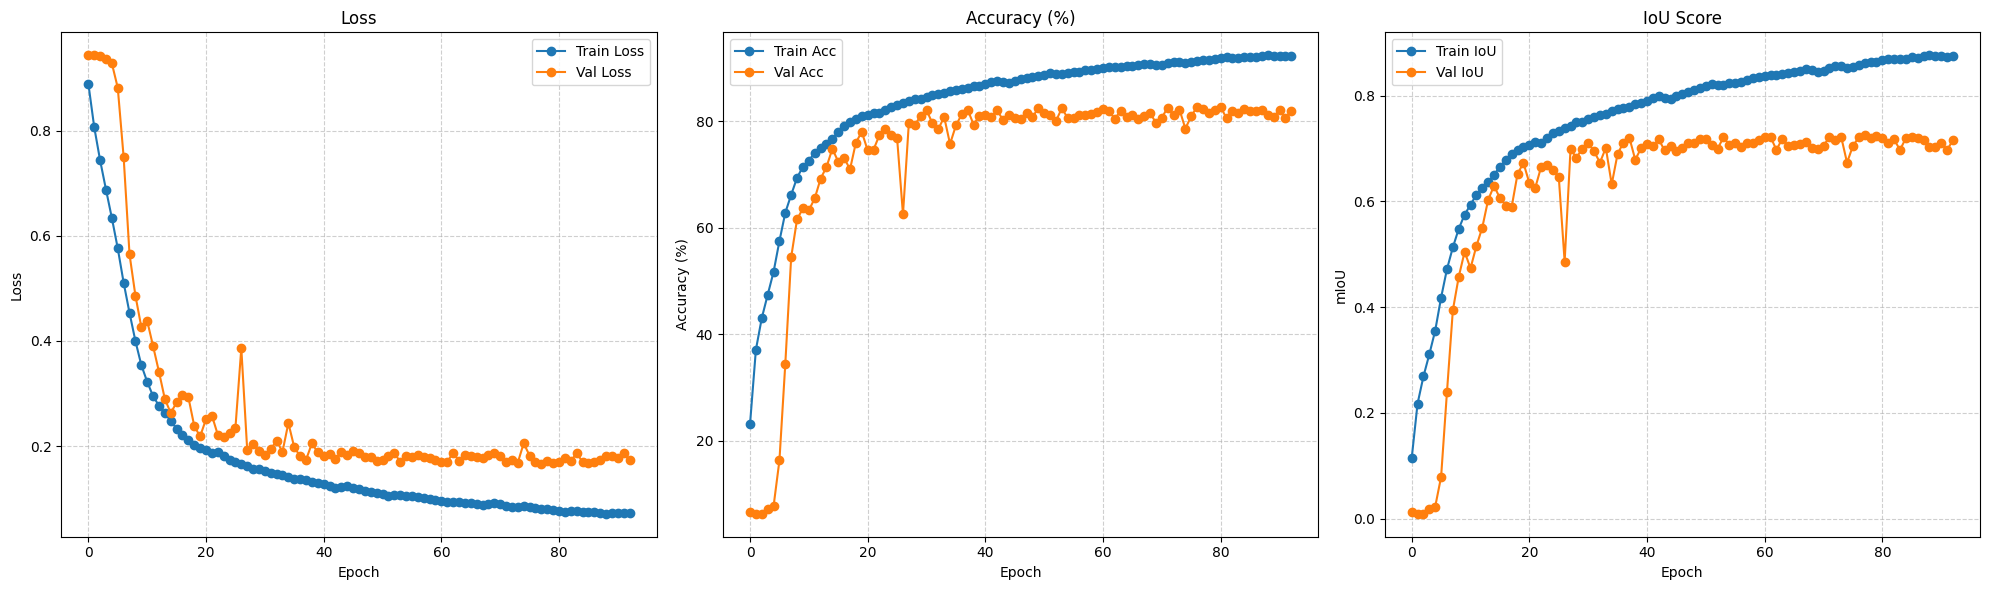

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_final_metrics(csv_path):
    df = pd.read_csv(csv_path)

    #Take the average value per epoch
    epoch_metrics = df.groupby('epoch').mean().reset_index()

    plt.figure(figsize=(20, 6))

    # Plot Loss
    plt.subplot(1, 3, 1)
    plt.plot(epoch_metrics['epoch'], epoch_metrics['train_loss'], label='Train Loss', marker='o')
    plt.plot(epoch_metrics['epoch'], epoch_metrics['val_loss'], label='Val Loss', marker='o')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epoch_metrics['epoch'], epoch_metrics['train_acc'] * 100, label='Train Acc', marker='o')
    plt.plot(epoch_metrics['epoch'], epoch_metrics['val_acc'] * 100, label='Val Acc', marker='o')
    plt.title('Accuracy (%)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Plot IoU Score
    plt.subplot(1, 3, 3)
    plt.plot(epoch_metrics['epoch'], epoch_metrics['train_mIoU'], label='Train IoU', marker='o')
    plt.plot(epoch_metrics['epoch'], epoch_metrics['val_mIoU'], label='Val IoU', marker='o')
    plt.title('IoU Score')
    plt.xlabel('Epoch')
    plt.ylabel('mIoU')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

log_path = "/content/logs/sentinel_unet_experiment/version_1/metrics.csv"
plot_final_metrics(log_path)

### Inference Model 

In [ ]:
from Model.unet_model import SentinelUNet
import torch
import rasterio
from rasterio.windows import Window
import numpy as np

# Load your best model
checkpoint_path = "/content/logs/sentinel_unet_experiment/version_1/checkpoints/best-sentinel-unet.ckpt"
model = SentinelUNet.load_from_checkpoint(checkpoint_path)
model.eval()
model.to("cuda")

In [ ]:
import torch.nn.functional as F

input_raster = "/content/drive/MyDrive/raster_sentinel.tif"
output_raster = "/content/drive/MyDrive/sentinel_classification.tif"

tile_size = 256
multiple = 16 

with rasterio.open(input_raster) as src:
    profile = src.profile

    profile.update(
        dtype=rasterio.uint8,
        count=1,
        compress='lzw',
        tiled=True, 
        blockxsize=tile_size,
        blockysize=tile_size
    )

    with rasterio.open(output_raster, 'w', **profile) as dst:
        for y in range(0, src.height, tile_size):
            for x in range(0, src.width, tile_size):

                window = Window(x, y, min(tile_size, src.width - x), min(tile_size, src.height - y))
                img_data = src.read(window=window).astype(np.float32)

                #Padding
                h, w = img_data.shape[1], img_data.shape[2]

                #Calculate the remainder to make it a multiple of 16
                pad_h = (multiple - h % multiple) % multiple
                pad_w = (multiple - w % multiple) % multiple

                input_tensor = torch.from_numpy(img_data).unsqueeze(0).to("cuda")

                #Provide padding (left, right, top, bottom)
                if pad_h > 0 or pad_w > 0:
                    input_tensor = F.pad(input_tensor, (0, pad_w, 0, pad_h), mode='constant', value=0)

                #Prediction
                with torch.no_grad():
                    output = model(input_tensor)
                    preds = torch.argmax(output, dim=1).squeeze(0)

                #Crop the prediction results back to the original window size
                if pad_h > 0 or pad_w > 0:
                    preds = preds[:h, :w]

                dst.write(preds.cpu().numpy().astype(rasterio.uint8), 1, window=window)

print("Inference complete! Files saved in:", output_raster)

Inferensi selesai! File tersimpan di: /content/drive/MyDrive/Thesis/Running CL 16 Kelas/linkedin/hasil_klasifikasi.tif


### Visualization

In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

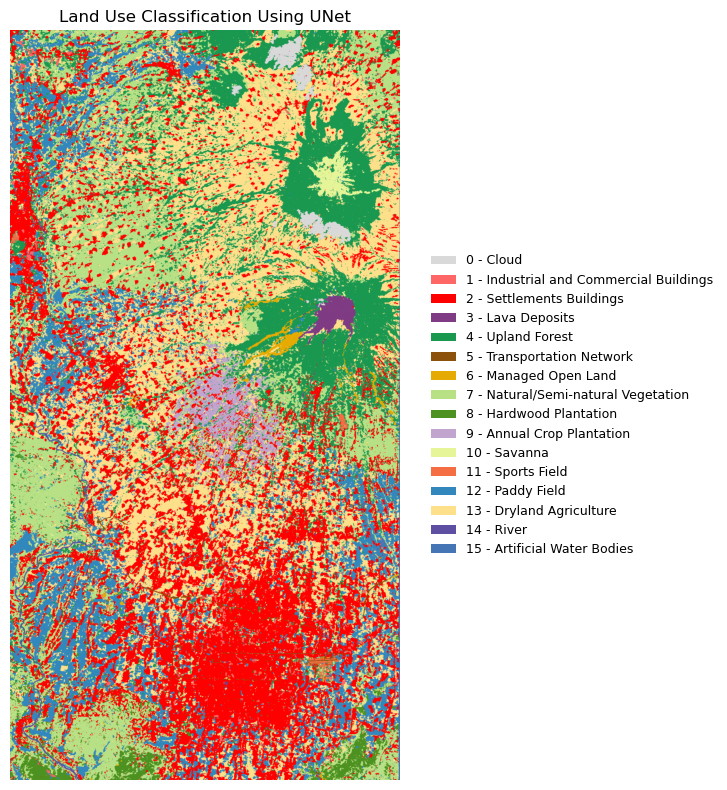

In [ ]:
#Read Raster Prediction
raster_path = r"result_inference.tif"
with rasterio.open(raster_path) as src:
    data = src.read(1)
    profile = src.profile
    pixel_size_x, pixel_size_y = src.res  # resolusi piksel (ex: 10x10 m)

# Define Class and Colors
classes = [
    'Cloud',
    'Industrial and Commercial Buildings',
    'Settlements Buildings',
    'Lava Deposits',
    'Upland Forest',
    'Transportation Network',
    'Managed Open Land',
    'Natural/Semi-natural Vegetation',
    'Hardwood Plantation',
    'Annual Crop Plantation',
    'Savanna',
    'Sports Field',
    'Paddy Field',
    'Dryland Agriculture',
    'River',
    'Artificial Water Bodies'
]

colors = [
    "#d9d9d9",  
    "#ff6666",   
    "#ff0000",  
    "#7f3b83", 
    "#1a9850", 
    "#8c510a", 
    "#e6ab02", 
    "#b8e186", 
    "#4d9221", 
    "#c2a5cf",  
    "#e6f598",  
    "#f46d43", 
    "#3288bd",  
    "#fee08b", 
    "#5e4fa2",  
    "#4575b4"   
]

#Visualization
cmap = ListedColormap(colors)
bounds = np.arange(-0.5, len(classes) + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(10, 8))
plt.imshow(data, cmap=cmap, norm=norm)
plt.title("Land Use Classification Using UNet", fontsize=12)
plt.axis("off")

legend_elements = [Patch(facecolor=colors[i], label=f"{i} - {classes[i]}") for i in range(len(classes))]
plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=9, frameon=False)
plt.tight_layout()

output_path = r"result_land_use_classification.png"

plt.savefig(
    output_path,
    dpi=400,            
    bbox_inches='tight',
    pad_inches=0.1,     
    transparent=False  
)
plt.show()